In [2]:
from dotenv import load_dotenv
import os

# Load .env from current directory
load_dotenv()

# Verify 
token = os.getenv("KAGGLE_API_TOKEN")
print("KAGGLE_API_TOKEN loaded from .env?", "Yes" if token else "No")

KAGGLE_API_TOKEN loaded from .env? Yes


In [ ]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import pandas as pd
import random

print("Loading local PlantVillage dataset...")

# Path to color images 
DATA_DIR = "./data/plantvillage/color"

#  folder check
import pathlib
print("Folder exists?", pathlib.Path(DATA_DIR).exists())
print("Number of class folders:", len(list(pathlib.Path(DATA_DIR).iterdir())))

# Load using imagefolder (auto-detects classes from subfolder names)
dataset = load_dataset("imagefolder", data_dir=DATA_DIR)

#  'train' split     contains all images + labels
ds = dataset['train']

print("\n Loaded successfully!")
print("Features:", ds.features)
print("Total images:", len(ds))
print("Number of classes:", ds.features['label'].num_classes)
print("\nFirst 10 class names:")
print(ds.features['label'].names[:10])

Loading local PlantVillage dataset...
Folder exists? True
Number of class folders: 38


Computing checksums: 100%|██████████| 54305/54305 [00:07<00:00, 6981.99it/s]
Generating train split: 54305 examples [00:07, 7214.80 examples/s]



 Loaded successfully!
Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold',

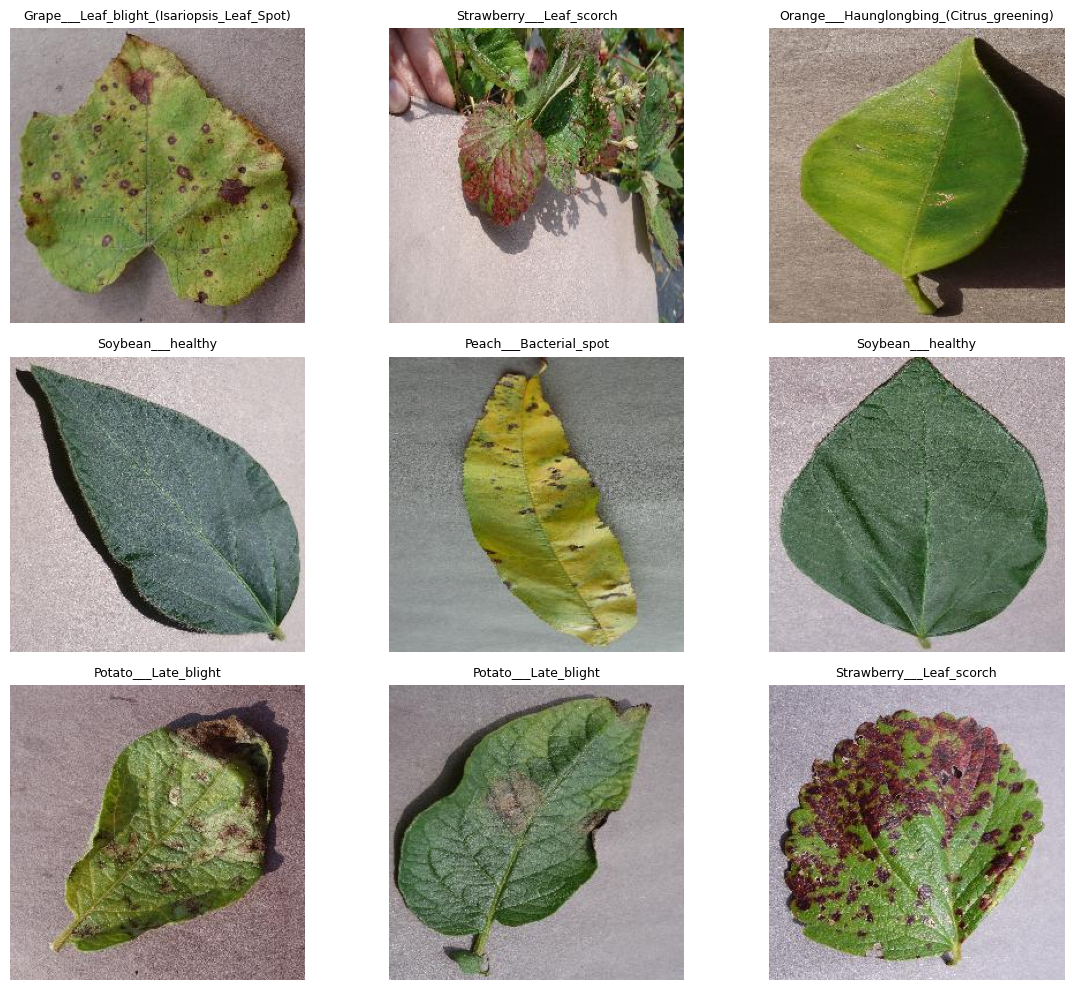

In [6]:
indices = random.sample(range(len(ds)), 9)

plt.figure(figsize=(12, 10))
for i, idx in enumerate(indices):
    example = ds[idx]
    img = example['image']
    label_str = ds.features['label'].int2str(example['label'])
    
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.title(label_str, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
labels = [ds.features['label'].int2str(x['label']) for x in ds]
df = pd.DataFrame({'label': labels})

print("Images per class (top 15 most images):")
print(df['label'].value_counts().head(15))

print("\nTotal classes:", df['label'].nunique())
print("Least represented class has:", df['label'].value_counts().min(), "images")

Images per class (top 15 most images):
label
Orange___Haunglongbing_(Citrus_greening)         5507
Tomato___Tomato_Yellow_Leaf_Curl_Virus           5357
Soybean___healthy                                5090
Peach___Bacterial_spot                           2297
Tomato___Bacterial_spot                          2127
Tomato___Late_blight                             1909
Squash___Powdery_mildew                          1835
Tomato___Septoria_leaf_spot                      1771
Tomato___Spider_mites Two-spotted_spider_mite    1676
Apple___healthy                                  1645
Tomato___healthy                                 1591
Blueberry___healthy                              1502
Pepper,_bell___healthy                           1478
Tomato___Target_Spot                             1404
Grape___Esca_(Black_Measles)                     1383
Name: count, dtype: int64

Total classes: 38
Least represented class has: 152 images
